# Monte carlo simulering av transporttid

                                     Rute  Forventet ledetid (dager)  Std.avvik   P10  Median   P90  Sannsynlighet innen frist (%)
  Rute 2: Karmøy - Rostock - Tog - Balkan                      10.56       0.82  9.50   10.53 11.64                           95.7
Rute 1: Karmøy - Rotterdam - Tog - Balkan                      11.24       0.83 10.18   11.22 12.32                           81.7


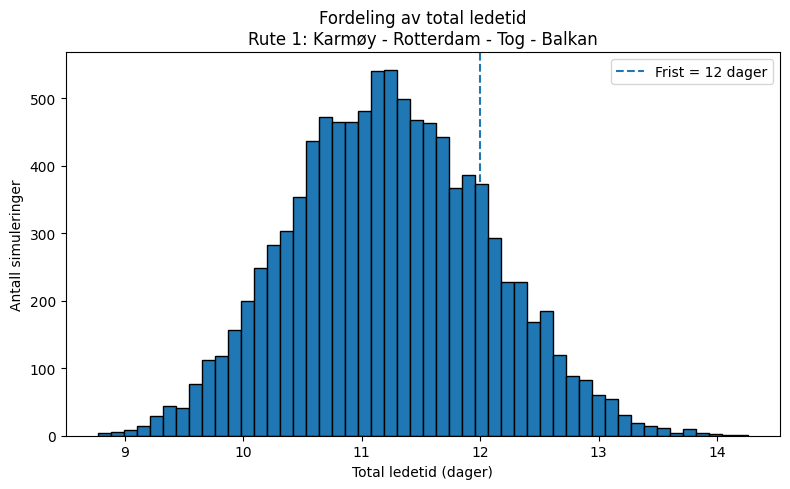

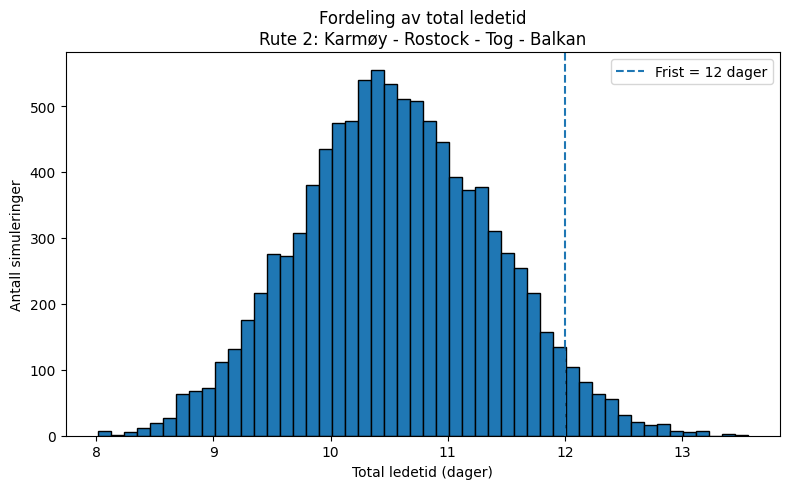

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Antall simuleringer
N = 10000

delivery_deadline = 12

# Ruter fra Karmøy til Balkan
# Hver etappe er definert som (min, mode, max)
routes = {
    "Rute 1: Karmøy - Rotterdam - Tog - Balkan": {
        "Håndtering og klargjøring på Vestlandet": (0.2, 0.4, 0.8),
        "Sjøtransport Karmøy til Rotterdam": (3.5, 4.5, 6.0),
        "Terminal og omlasting i Rotterdam": (0.5, 1.0, 2.0),
        "Togtransport fra Rotterdam til Balkan": (2.5, 3.5, 5.0),
        "Terminal nær mottaker": (0.3, 0.6, 1.2),
        "Siste veitransport til kunde": (0.2, 0.5, 1.0),
    },
    "Rute 2: Karmøy - Rostock - Tog - Balkan": {
        "Håndtering og klargjøring på Karmøy": (0.2, 0.4, 0.8),
        "Sjøtransport Karmøy til Rostock": (2.5, 3.5, 5.0),
        "Terminal og omlasting i Rostock": (0.4, 0.8, 1.8),
        "Togtransport fra Rostock til Balkan": (3.0, 4.0, 5.5),
        "Terminal nær mottaker": (0.3, 0.6, 1.2),
        "Siste veitransport til kunde": (0.2, 0.5, 1.0),
    }
}

def simulate_route(route_data, N):
    total_time = np.zeros(N)

    for stage, (minimum, mode, maximum) in route_data.items():
        samples = np.random.triangular(minimum, mode, maximum, N)
        total_time += samples

    return total_time

simulation_results = {}
summary_rows = []

for route_name, route_data in routes.items():
    total_times = simulate_route(route_data, N)
    simulation_results[route_name] = total_times

    summary_rows.append({
        "Rute": route_name,
        "Forventet ledetid (dager)": round(np.mean(total_times), 2),
        "Std.avvik": round(np.std(total_times), 2),
        "P10": round(np.percentile(total_times, 10), 2),
        "Median": round(np.percentile(total_times, 50), 2),
        "P90": round(np.percentile(total_times, 90), 2),
        "Sannsynlighet innen frist (%)": round(np.mean(total_times <= delivery_deadline) * 100, 1)
    })

summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df.sort_values(by="Sannsynlighet innen frist (%)", ascending=False)

print(summary_df.to_string(index=False))

for route_name, total_times in simulation_results.items():
    plt.figure(figsize=(8, 5))
    plt.hist(total_times, bins=50, edgecolor="black")
    plt.axvline(delivery_deadline, linestyle="--", label=f"Frist = {delivery_deadline} dager")
    plt.title(f"Fordeling av total ledetid\n{route_name}")
    plt.xlabel("Total ledetid (dager)")
    plt.ylabel("Antall simuleringer")
    plt.legend()
    plt.tight_layout()
    plt.show()